# Exact-match response caching with Oracle True Cache
-----------------

An **exact-match response cache** stores the answer to a request under a key built from every input
that decides the answer. 

When the identical request arrives again, the stored answer is returned and
the model is not called. 

It is the oldest and simplest form of caching, and for an AI agent it is
often the cheapest win: a lookup takes milliseconds, a model call takes seconds and costs money.

This notebook keeps the cache in **Oracle AI Database** and serves its reads from **Oracle True
Cache**, a read-only, in-memory database instance that sits in front of the primary database and
keeps itself up to date from the primary's redo. Writes go to the primary; reads go to True Cache;
there is no invalidation code for the cache tier.

> The use case is a **GitHub issue-triage agent**. 
>
> Webhooks are delivered *at least once*, and several
> agent workers consume them, so the same `issues.opened` payload reaches the agent more than once.
>
> Every repeat would otherwise be another identical model call.

**What you will build and measure**

- A canonical request and a SHA-256 cache key that ignore per-delivery noise but capture everything the
  model sees.
- An Oracle table on the primary that stores each triage as `JSON` with an application-owned expiry.
- A lookup that reads through True Cache first and falls back to the primary, so a write that has not
  reached True Cache yet never causes a second model call.
- Real measurements for every delivery: latency, which tier answered, Claude calls and estimated cost,
  plus the replication lag between the primary and True Cache.

**What you need:** an Anthropic API key, a primary Oracle AI Database with a True Cache instance in front
of it (the container setup is described in Part 3), and internet access for the first download of the
public SWE-bench Lite dataset. The notebook makes five Claude calls.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1 · How exact-match caching on True Cache works

## 1.1 · The idea

Many calls an agent makes are **pure functions of their inputs**: the same model, prompt and input
text produce an answer you are happy to reuse. Classifying a ticket, summarising a document,
extracting fields from a form and triaging an issue all fit this shape.

An exact-match cache turns that observation into a lookup table:

1. Reduce the request to the inputs that decide the answer, in one normal form.
2. Hash that normal form into a fixed-length **key**.
3. If the key is present and still fresh, return the stored answer. Otherwise call the model, store
   the answer under the key, and return it.

What is reused is the **whole response**. What is skipped is the model call: no input tokens, no output
tokens, no network round trip to the provider and no seconds of generation. The price is one database
lookup per request, plus one write per miss.

"Exact" is the important word. The cache never decides that two *different* requests are close enough;
that is the job of a semantic cache. Because a hit requires byte-for-byte identical canonical inputs, an
exact cache cannot return an answer to a different question. Its risks are elsewhere: a key that leaves
out something the answer depends on, and answers that go stale.

## 1.2 · What Oracle True Cache adds

The cache has to live somewhere every agent worker can see. Traditionally that is a separate key-value
store in front of the database, which brings a second data model, a second system to operate, and
application code that must invalidate or update the cache whenever the database changes.

**Oracle True Cache** takes a different approach. It is an Oracle Database instance that acts as a
read-only, in-memory replica of a primary database:

- **Mostly diskless and in memory.** It starts empty and fills its buffer cache with the blocks your
  queries touch, fetching them from the primary on demand. Frequently read data stays in memory.
- **Kept current by redo apply.** Once a block is cached, changes committed on the primary are applied
  to it from the primary's redo stream, the same mechanism Active Data Guard uses. You do not write any
  invalidation or refresh code.
- **Read-consistent, slightly behind.** A query on True Cache only ever sees committed, consistent data,
  but that data can lag the primary by a short time.
- **Read-only.** Writes go to the primary. A write sent to True Cache is refused, unless you opt into
  DML redirection, which forwards it to the primary.
- **Same SQL, same data model.** The application connects to a True Cache *service* and runs ordinary
  SQL against the same tables. Choosing the connection is the only change: reads that can tolerate a
  small lag go to True Cache; writes and reads that need the newest data go to the primary.

| | Application-managed key-value cache | Oracle True Cache |
|---|---|---|
| Data model | Separate (keys and serialised values) | The same tables and SQL as the primary |
| Keeping it current | Your code invalidates or updates entries | Redo apply from the primary, automatically |
| Writes | Dual writes: database and cache | Primary only |
| Consistency | Whatever your invalidation code achieves | Committed, consistent data with a small lag |
| Security | Separate access control | The primary's users, roles and policies |

In this notebook the **table of record** for cached answers is an ordinary table on the primary. True
Cache is the fast read path in front of it.

## 1.3 · The request flow

The diagram follows one webhook delivery through the cache. Solid arrows are calls the agent makes;
the dotted arrow is replication that happens without any agent code.

**Figure · One delivery through True Cache, the primary and Claude**

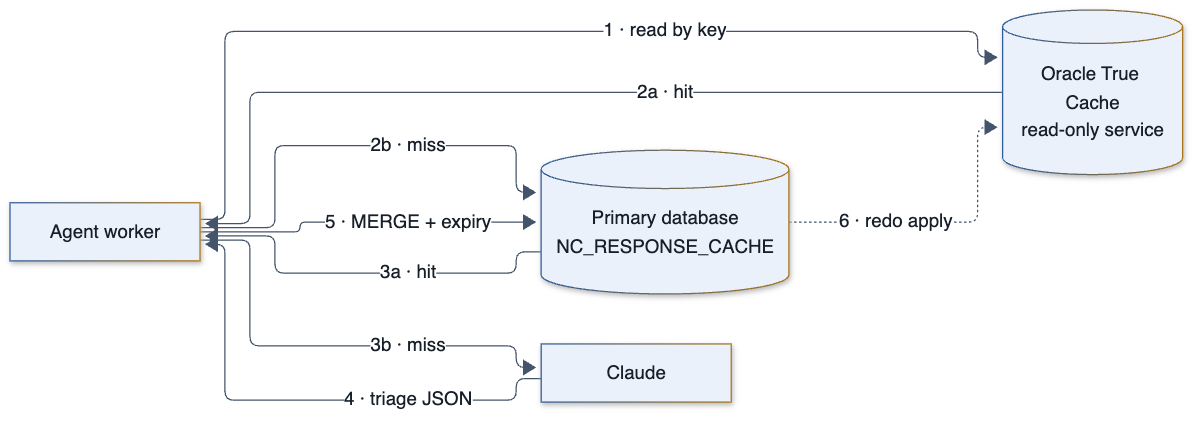

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    W["Agent worker"] -->|"1 · read by key"| TC[("Oracle True Cache<br/>read-only service")]
    TC -->|"2a · hit"| W
    W -->|"2b · miss"| P[("Primary database<br/>NC_RESPONSE_CACHE")]
    P -->|"3a · hit"| W
    W -->|"3b · miss"| C["Claude"]
    C -->|"4 · triage JSON"| W
    W -->|"5 · MERGE + expiry"| P
    P -.->|"6 · redo apply"| TC
```

</details>

Step by step:

1. **Read by key.** The worker builds the canonical request, hashes it, and queries True Cache for a row
   with that key whose `expires_at` is still in the future.
2. **True Cache answers.**
   - **2a.** A fresh row is found: the stored triage is returned. Nothing else happens.
   - **2b.** No row. That is either a genuine miss or a row that was committed on the primary moments ago
     and has not been applied to True Cache yet.
3. **The primary answers.** The worker repeats the same query on the primary, the table of record.
   - **3a.** Found: the row was simply in flight. The worker reuses it and still skips the model.
   - **3b.** Not found: a genuine miss.
4. **Claude.** The worker sends the canonical request to the model and receives the triage.
5. **Write.** The worker upserts the answer on the primary with `MERGE`, stamping an expiry time.
6. **Redo apply.** The primary's redo carries the new row to True Cache. The next delivery of the same
   payload, on any worker, is answered at step 2a.

Step 3 is the price of a cache that can lag: one extra primary query on a True Cache miss. It is far
cheaper than the model call it can prevent.

## 1.4 · What makes two requests the same

The key must contain **everything the answer depends on** and **nothing that varies between identical
requests**. For the triage agent:

| In the key | Why |
|---|---|
| Repository (scope) | Triage depends on the project's components and conventions; one repository's answer must never be served to another. |
| Model | A different model can give a different answer. |
| Prompt version | The system prompt is the agent's procedure. Changing it changes the answers, so the version is part of the key. |
| `max_tokens` | A shorter limit can truncate the answer. |
| Issue title and body | The input itself, exactly as the model sees it. |


| Kept out of the key | Why |
|---|---|
| Delivery ID, receipt time | Different on every delivery of the same event. Including them would make every redelivery a miss. |
| Worker name | Any worker should be able to reuse any other worker's answer. |

**Canonicalisation** makes equal inputs hash equally. Here it means converting Windows line endings
(`\r\n`) to `\n`, trimming leading and trailing whitespace, and truncating the body at the same limit
the model call uses. It deliberately does *not* lower-case text or collapse spaces inside the body:
code blocks and stack traces are whitespace- and case-sensitive.

The rule that keeps an exact cache correct: **the model must see only what is in the key.** Build the
prompt from the canonical request, never from the raw payload.

## 1.5 · Freshness, expiry and invalidation

Two different questions are easy to mix up:

1. **Is True Cache in step with the table of record?** That is True Cache's job. Inserts, updates and
   deletes committed on the primary reach True Cache through redo apply. You write no invalidation code
   for the cache tier, and you can delete a cached answer for every worker with one `DELETE` on the
   primary.
2. **Is the stored answer still the right answer?** That is your application's rule. True Cache will
   faithfully serve a stale answer if the table still holds it. This notebook uses three tools:
   - an **expiry time** (`expires_at`) on every row, checked in the `WHERE` clause of every read;
   - **versioned keys**: bumping the prompt version makes every old answer unreachable at once;
   - **input in the key**: an edited issue has a different key, so it is triaged afresh.

## 1.6 · When it helps and when it hurts

**It helps when identical requests repeat.** At-least-once message delivery, client retries, several
workers on one queue, scheduled re-runs and popular documents all produce exact repeats. Each repeat
costs a millisecond-scale lookup instead of a multi-second model call.

**It hurts, or does nothing, when:**

- requests rarely repeat exactly: every request pays the lookup and the write and gains nothing;
- you *want* a fresh, varied answer each time (creative generation, sampling several candidates);
- the answer depends on something outside the key, such as the current date or the user's permissions;
  then the cache returns answers that are confidently wrong;
- the TTL is longer than the time the answer stays true.

**True Cache specifics.** Reads can lag writes slightly, so read-your-own-writes needs the primary
fallback shown above. True Cache also needs enough memory for the rows you read often; rows that are
not in memory are fetched from the primary on demand.

### Takeaways

- An exact cache reuses a whole response when the canonical inputs are identical, and skips the model call.
- The key must include everything the answer depends on (scope, model, prompt version, limits, input) and
  nothing per-delivery.
- True Cache serves the cache reads from memory and stays current through redo apply, so the cache tier
  needs no invalidation code.
- Freshness of the *answer* is still yours: expiry times and versioned keys.
- Read through True Cache, fall back to the primary, and only then call the model.

# Part 2 · The use case: an issue-triage agent behind at-least-once webhooks

## 2.1 · The scenario

A team runs an agent that triages new GitHub issues. GitHub sends an `issues.opened` webhook; the
agent asks Claude to classify the issue (component, severity, a one-line summary, suggested labels) and
applies the labels.

Webhook delivery is **at least once**. The same event reaches the agent more than once when:

- the receiver is slow to acknowledge and the sender retries;
- someone redelivers a failed delivery from the repository settings;
- a worker crashes after calling the model but before acknowledging the message, and the queue hands
  the message to another worker;
- a backfill job replays recent events.

Without a cache, each of these is a full model call that produces an answer the agent already has. With
several workers the repeats can land on different machines within seconds of each other, so the cache
must be **shared** across workers, not a dictionary inside one process.

The issues in this notebook are real: they come from **SWE-bench Lite**, a public dataset of GitHub
issues from popular Python projects, pinned to a fixed revision.

## 2.2 · Where the cache sits in the agent's memory

It helps to place the cache among the kinds of memory an agent uses:

| Memory | In the triage agent |
|---|---|
| **Working memory** | The issue payload and the prompt for the current delivery. Gone when the delivery is done. |
| **Procedural memory** | *How* to triage: the versioned system prompt. A new version is a new procedure, so it gets new keys. |
| **Semantic memory** | Knowledge about the repository: its components and label scheme. |
| **Episodic memory** | What happened: which deliveries were processed, which labels were applied and when. |

The response cache is a **memory of a computation the agent has already done**: "for exactly this
input, under this procedure, the triage was X". Its purpose is **idempotency**, so that a repeated
event does not repeat the work.

It is **not** the memory of record. The issue on GitHub is the source of truth, and the triage is a
derived opinion about it. That is why every entry is scoped by repository and prompt version and
carries an expiry: the cache may forget an answer at any time, and the agent can always recompute it.
Applying labels is a separate side effect that needs its own idempotency check; never treat a cache
hit as proof that an action was carried out.

**Figure · The triage agent with its shared response cache**

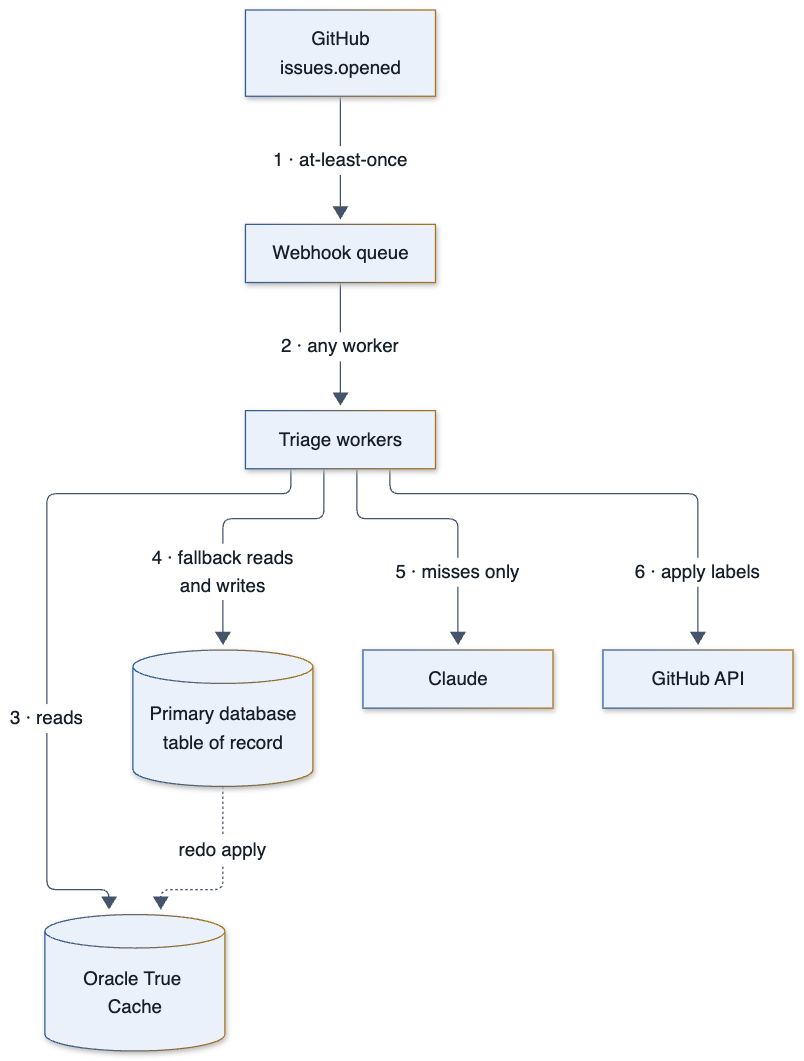

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    GH["GitHub<br/>issues.opened"] -->|"1 · at-least-once"| Q["Webhook queue"]
    Q -->|"2 · any worker"| W["Triage workers"]
    W -->|"3 · reads"| TC[("Oracle True Cache")]
    W -->|"4 · fallback reads<br/>and writes"| P[("Primary database<br/>table of record")]
    P -.->|"redo apply"| TC
    W -->|"5 · misses only"| C["Claude"]
    W -->|"6 · apply labels"| API["GitHub API"]
```

</details>

The workers never talk to each other. They share answers only through the table on the primary, and
they read those answers through True Cache. Adding a worker adds read load on True Cache, not on the
primary.

### Takeaways

- At-least-once delivery and multiple workers make exact repeats normal, not exceptional.
- The cache must be shared across workers; a table on the primary read through True Cache is shared by
  construction.
- The cache is an idempotency record of past computations, scoped by repository and procedure version.
  GitHub stays the source of truth.

# Part 3 · Set up

## 3.1 · How the True Cache pair is set up

The notebook needs two database services:

- **The primary**, an Oracle AI Database with archive logging enabled. It owns the cache table and takes
  every write. Default address: `127.0.0.1:1525/FREEPDB1`.
- **True Cache**, a second Oracle AI Database instance started in True Cache mode and attached to the
  primary. A True Cache application service is registered for the pluggable database, and that service
  is where reads go. Default address: `127.0.0.1:1526/sales_pdb_tc`.

Both can run locally from Oracle's free container image: the same image is started once as the primary
and once with `TRUE_CACHE=true`, and `dbca` on the primary registers the True Cache service. The exact
commands are in the **True Cache setup** section of `README.md`.

The application connects as a **dedicated user** created on the primary with `CREATE SESSION`,
`CREATE TABLE` and a tablespace quota. Users, tables and rows replicate to True Cache, so the same
credentials work on both services. Set `TRUE_CACHE_USER` and `TRUE_CACHE_PASSWORD` (or answer the
prompts), and `PRIMARY_DSN` / `TRUE_CACHE_DSN` if your addresses differ from the defaults.

## 3.2 · Imports

Standard-library modules handle hashing, JSON, timing and IDs. `oracledb` is the Oracle driver (thin
mode, no client libraries needed), `anthropic` is the raw Claude SDK, and pandas and matplotlib show the
measurements.

In [2]:
import hashlib
import json
import os
import statistics
import threading
import time
import uuid
from getpass import getpass

import matplotlib.pyplot as plt
import oracledb
import pandas as pd
from anthropic import Anthropic
from IPython.display import display

## 3.3 · Run settings

- `RUN_ID` scopes every row this notebook writes. Running the notebook again uses a new ID, so earlier
  runs can never turn a first delivery into a hit. In production the scope would be the deployment or
  tenant rather than a run.
- `TABLE` is the cache table on the primary.
- `MEASUREMENTS` collects one row per handled delivery; `LAST_WRITE` remembers the most recent write.

In [3]:
RUN_ID = uuid.uuid4().hex[:12]
TABLE = "NC_RESPONSE_CACHE"
MEASUREMENTS = []
LAST_WRITE = {}
print("Run", RUN_ID)

Run e012fe7e680b


### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [4]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

### Price every Claude call from reported usage

Every response from the Anthropic API reports how many tokens it processed. The prices below
are the published list prices for Claude Opus 5.5 (USD per million tokens, checked on
2026-10-03). Each counter is priced separately:

- `input`: ordinary prompt tokens.
- `cache_write`: prompt tokens written to Anthropic's prompt cache (1.25× input).
- `cache_read`: prompt tokens read back from that cache (0.05× input on Opus 5.5).
- `output`: generated tokens, the most expensive counter.

`LLM_CALLS` is a ledger: one row per real request, so every cost in this notebook can be
traced back to an actual API response. These are list-price estimates, not an invoice.

In [5]:
MODEL = "claude-opus-5-5"
PRICE = {"input": 4.00, "cache_write": 5.00, "cache_read": 0.20, "output": 20.00}
LLM_CALLS = []


def llm_cost(usage):
    """Price one response from the token counters the API returned."""
    tokens = {
        "input": usage.input_tokens,
        "cache_write": usage.cache_creation_input_tokens or 0,
        "cache_read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000

### One function for every model call

`ask_claude()` sends a single request with the raw Anthropic SDK. `system` is either a plain
string or a list of content blocks (the list form is what lets a block carry a prompt-cache
breakpoint). `effort="low"` asks the model for a direct answer, which keeps latency and
output tokens down. The function records latency, the four token counters and the estimated
cost in `LLM_CALLS`, then returns only the visible text.

In [6]:
def ask_claude(system, user, max_tokens=1024):
    """Send one request, record latency, tokens and cost, and return the answer text."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role": "user", "content": user}],
        output_config={"effort": "low"},
    )
    tokens, usd = llm_cost(response.usage)
    seconds = time.perf_counter() - started
    LLM_CALLS.append({"seconds": seconds, **tokens, "usd": usd})
    return "".join(b.text for b in response.content if b.type == "text")

Create the client. The key is read with `secret()`; the client object keeps it in memory
only. A timeout and two retries keep a slow network from hanging the notebook.

In [7]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

## 3.4 · Connect to the primary and to True Cache

The application keeps **two explicit connections**: `primary` for writes and fallback reads, `cache` for
the True Cache service. Choosing the connection by intent (read versus write) is the whole application
change True Cache asks for. The credentials are read once; `connect()` refuses administrator accounts
because an application cache should never run with `SYS` or `SYSTEM` privileges.

In [8]:
APP_USER = os.getenv("TRUE_CACHE_USER") or input("Application user: ").strip()
APP_PASSWORD = os.getenv("TRUE_CACHE_PASSWORD") or getpass("Application password: ")


def connect(variable, default):
    """Connect as the application user to the service named in an environment variable."""
    if APP_USER.lower() in {"sys", "system"}:
        raise ValueError("Use a dedicated application user.")
    return oracledb.connect(
        user=APP_USER, password=APP_PASSWORD, dsn=os.getenv(variable, default)
    )


primary = connect("PRIMARY_DSN", "127.0.0.1:1525/FREEPDB1")
cache = connect("TRUE_CACHE_DSN", "127.0.0.1:1526/sales_pdb_tc")

### Which database is each connection talking to?

`SYS_CONTEXT('USERENV', ...)` reports facts about the current session without needing any extra
privileges. `DATABASE_ROLE` is `PRIMARY` on the primary. On True Cache it reports `PHYSICAL STANDBY`,
because True Cache is built on the same redo-apply machinery as a standby database; an administrator
querying `V$DATABASE` on the instance sees the role `TRUE CACHE`, opened `READ ONLY WITH APPLY`.

**What to watch:** the `primary` column shows `PRIMARY` and the `FREEPDB1` service; the `true_cache`
column shows `PHYSICAL STANDBY` and the True Cache service name.

In [9]:
def describe(connection):
    """Return the database role and service name of a connection's session."""
    with connection.cursor() as cursor:
        cursor.execute("""
            SELECT SYS_CONTEXT('USERENV', 'DATABASE_ROLE'),
                   SYS_CONTEXT('USERENV', 'SERVICE_NAME')
            FROM dual""")
        role, service = cursor.fetchone()
    return {"database_role": role, "service": service}


display(pd.DataFrame({"primary": describe(primary), "true_cache": describe(cache)}))

,primary,true_cache
database_role,PRIMARY,PHYSICAL STANDBY
service,freepdb1,sales_pdb_tc


## 3.5 · Load real issues from SWE-bench Lite

pandas reads the dataset's Parquet file straight from Hugging Face through the `hf://` protocol. The
`@b0dde10…` part pins an exact dataset revision, so the issues never change under you. Only four
columns are read.

SWE-bench identifies each issue by the pull request that resolved it (`instance_id`). The first line of
`problem_statement` is the issue title and the rest is the body. The cell shows the first issue from
three repositories; the agent will triage the Django one.

In [10]:
SWE_BENCH = (
    "hf://datasets/SWE-bench/SWE-bench_Lite@b0dde1093fe417d83b7184254edf8199c1f0dff5"
    "/data/test-00000-of-00001.parquet"
)
columns = ["instance_id", "repo", "problem_statement", "created_at"]
issues = pd.read_parquet(SWE_BENCH, columns=columns)
repos = ["django/django", "pytest-dev/pytest", "sympy/sympy"]
picked = (
    issues[issues.repo.isin(repos)].sort_values("instance_id").groupby("repo").head(1)
)
picked = picked.assign(
    title=picked.problem_statement.str.split("\n").str[0].str.strip()
)
display(picked[["instance_id", "repo", "created_at", "title"]])

,instance_id,repo,created_at,title
6,django__django-10914,django/django,2019-01-30T13:13:20Z,Set default FILE_UPLOAD_PERMISSION to 0o644.
167,pytest-dev__pytest-11143,pytest-dev/pytest,2023-06-26T06:44:43Z,Rewrite fails when first expression of file is...
223,sympy__sympy-11400,sympy/sympy,2016-07-15T21:40:49Z,ccode(sinc(x)) doesn't work


### Shape a row like a webhook payload

`webhook_payload()` keeps the parts of a GitHub `issues.opened` event the agent reads: the action, the
repository and the issue's title and body. `deliver()` wraps a payload the way a queue hands it to a
worker: each delivery gets its **own** delivery ID and receipt time, exactly the per-delivery noise the
cache key must ignore.

In [11]:
def webhook_payload(row):
    """The parts of an issues.opened event that the triage agent reads."""
    title, _, body = row.problem_statement.partition("\n")
    issue = {"source_id": row.instance_id, "title": title, "body": body}
    return {"action": "opened", "repository": row.repo, "issue": issue}


def deliver(payload):
    """Wrap a payload as one delivery; every delivery has its own ID and receipt time."""
    return {
        "delivery_id": str(uuid.uuid4()),
        "received_at": time.time(),
        "payload": payload,
    }

The issue the agent will see over and over again:

In [12]:
ISSUE = webhook_payload(picked.iloc[0])
print(ISSUE["repository"], "·", ISSUE["issue"]["source_id"])
print("Title:", ISSUE["issue"]["title"])
print("Body:", len(ISSUE["issue"]["body"]), "characters")

django/django · django__django-10914
Title: Set default FILE_UPLOAD_PERMISSION to 0o644.
Body: 976 characters


# Part 4 · Build the cache

## 4.1 · The cache table on the primary

`create_if_missing()` runs DDL and ignores only `ORA-00955` ("name is already used by an existing
object"), so re-running the notebook is safe; any other error, such as a missing privilege, is raised.
It takes the connection explicitly, because DDL only ever runs on the primary.

In [13]:
def create_if_missing(connection, sql):
    """Run DDL, ignoring only 'name is already used by an existing object'."""
    with connection.cursor() as cursor:
        try:
            cursor.execute(sql)
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

The table has one row per cached answer:

- `cache_key`: the SHA-256 of the canonical request, 64 hex characters, and the primary key, so a lookup
  is a single unique-index probe.
- `namespace`: the repository the answer belongs to, kept as a readable column for operations and audits.
- `run_id`: which run wrote the row; the cleanup cell deletes by it.
- `response`: the triage, stored with Oracle's native `JSON` type, so it is validated on insert and can be
  queried with SQL/JSON if you ever need to.
- `created_at` and `expires_at`: when the answer was stored and when it stops being served. Time zone
  aware timestamps avoid surprises when workers run in different regions.

In [14]:
create_if_missing(
    primary,
    f"""
    CREATE TABLE {TABLE} (
        cache_key   VARCHAR2(64) PRIMARY KEY,
        namespace   VARCHAR2(200) NOT NULL,
        run_id      VARCHAR2(32) NOT NULL,
        response    JSON NOT NULL,
        created_at  TIMESTAMP WITH TIME ZONE DEFAULT SYSTIMESTAMP NOT NULL,
        expires_at  TIMESTAMP WITH TIME ZONE NOT NULL
    )""",
)
print(TABLE, "is ready on the primary")

NC_RESPONSE_CACHE is ready on the primary


## 4.2 · The table appears on True Cache by itself

The `CREATE TABLE` above ran only on the primary. Its redo carries the dictionary change to True Cache.

`wait_until()` polls a check function until it returns something truthy and reports **when** that
happened (`time.perf_counter()` at the moment of success), so callers can compute how long a change took
to arrive. `table_visible()` asks the data dictionary, through a given connection, whether the table
exists.

**What to watch:** the table is visible through the True Cache connection without anyone creating it
there. On a re-run it already exists, so the wait is close to zero.

In [15]:
def wait_until(check, timeout=30, interval=0.005):
    """Poll check() until it is truthy; return (value, perf_counter time of success)."""
    started = time.perf_counter()
    while time.perf_counter() - started < timeout:
        value = check()
        if value:
            return value, time.perf_counter()
        time.sleep(interval)
    raise TimeoutError("The change did not reach True Cache in time.")

Run the check against True Cache:

In [16]:
def table_visible(connection):
    """True when the cache table exists in the data dictionary seen by this connection."""
    with connection.cursor() as cursor:
        cursor.execute(
            "SELECT COUNT(*) FROM user_tables WHERE table_name = :name", name=TABLE
        )
        return cursor.fetchone()[0] == 1


started = time.perf_counter()
_, seen_at = wait_until(lambda: table_visible(cache))
print(f"{TABLE} is visible through True Cache after {seen_at - started:.3f} s")

NC_RESPONSE_CACHE is visible through True Cache after 0.007 s


## 4.3 · The canonical request

`canonical_request()` turns a webhook payload into the exact set of inputs that decide the triage
answer, in one normal form. It is both the material for the cache key and **the only thing the model
will see**.

- `scope` holds the repository and this notebook's `RUN_ID`.
- `model`, `prompt_version` and `max_tokens` describe how the answer is produced.
- `title` is trimmed. `body` has Windows line endings converted to `\n`, is trimmed, and is cut at
  `BODY_LIMIT` characters, the same limit the prompt uses, so very long issues cost a bounded number of
  tokens.

Nothing about the delivery (ID, receipt time, worker) appears here.

In [17]:
PROMPT_VERSION = "triage-v1"
MAX_TOKENS = 400
BODY_LIMIT = 4000


def canonical_request(payload, prompt_version=PROMPT_VERSION):
    """Everything that decides the triage answer, in one normal form; nothing per delivery."""
    body = payload["issue"]["body"].replace("\r\n", "\n").strip()[:BODY_LIMIT]
    return {
        "scope": {"repository": payload["repository"], "run": RUN_ID},
        "model": MODEL,
        "prompt_version": prompt_version,
        "max_tokens": MAX_TOKENS,
        "title": payload["issue"]["title"].strip(),
        "body": body,
    }

## 4.4 · The cache key

`cache_key()` serialises the canonical request as JSON with **sorted keys** and compact separators, so
the same dictionary always produces the same bytes regardless of insertion order, and hashes those bytes
with SHA-256. The hex digest is the primary key in Oracle.

A hash is an identity, not a secret: it is safe to log and to show in dashboards.

In [18]:
def cache_key(request):
    """SHA-256 of the canonical request serialised with sorted keys."""
    raw = json.dumps(request, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    return hashlib.sha256(raw.encode()).hexdigest()

### Check the key against per-delivery noise

Three deliveries of the same issue: two plain redeliveries, and one whose body uses Windows line
endings (as text pasted from a Windows browser can).

**What to watch:** the two deliveries have different delivery IDs, yet all three produce a **single**
distinct key.

In [19]:
first, second = deliver(ISSUE), deliver(ISSUE)

windows = json.loads(json.dumps(ISSUE))

windows["issue"]["body"] = (
    ISSUE["issue"]["body"].replace("\r\n", "\n").replace("\n", "\r\n")
)

keys = {
    cache_key(canonical_request(d["payload"]))
    for d in (first, second, deliver(windows))
}

print("Different delivery IDs:", first["delivery_id"] != second["delivery_id"])
print("Distinct cache keys:", len(keys), "·", next(iter(keys))[:16], "…")

Different delivery IDs: True
Distinct cache keys: 1 · 03f087cee2c8b425 …


## 4.5 · Look up one key on one connection

`lookup()` runs the same SQL on whichever connection it is given:

- `WHERE cache_key = :key` is a primary-key probe.
- `AND expires_at > SYSTIMESTAMP` enforces the expiry at read time, so an expired row is a miss even
  before anything deletes it.
- The key is a **bind variable**, never pasted into the SQL text, which keeps the statement shareable
  and safe from injection.

Because the column is `JSON`, the driver returns the stored triage as a Python dictionary.

In [20]:
def lookup(connection, key):
    """Return the stored response if the row exists and has not expired, else None."""
    with connection.cursor() as cursor:
        cursor.execute(
            f"""
            SELECT response FROM {TABLE}
            WHERE cache_key = :key AND expires_at > SYSTIMESTAMP""",
            key=key,
        )
        row = cursor.fetchone()
    return row[0] if row else None

## 4.6 · Read through True Cache, then the primary

`read_cached()` implements steps 1 to 3 of the request flow. It tries True Cache first and, only on a
miss there, the primary. It returns the response and the name of the tier that answered, or
`(None, None)` for a genuine miss.

The primary fallback costs one extra query on a miss. It prevents a duplicate model call when a
redelivery arrives in the short window after another worker's write has committed on the primary but
before it has been applied on True Cache.

In [21]:
def read_cached(key):
    """Try True Cache, then the primary; return (response, tier) or (None, None)."""
    for tier, connection in (("true_cache", cache), ("primary", primary)):
        response = lookup(connection, key)
        if response is not None:
            return response, tier
    return None, None

## 4.7 · Write on the primary

Writes go to the primary only. `MERGE` is an upsert: if a row with the key exists it is refreshed, and
otherwise a new row is inserted.

`MERGE` alone does **not** make two simultaneous first writes safe. If two workers miss at the same moment,
neither can see the other's uncommitted row, so both take the insert branch. The primary key lets only
one row in: the second worker's statement waits for the first to commit and then fails with `ORA-00001`
(unique constraint violated). `merge_once()` below treats that one error as success, because the row
it wanted to store, an answer to the identical request, now exists. Part 5 runs this race for real.

Every bound value appears **once**, as a column of the one-row `USING` source `s`; the `UPDATE` and
`INSERT` branches refer to `s.response` and `s.ttl` instead of repeating the bind names. Binding the same
name in both branches can fail for large values, and this form is easier to read. `JSON(s.response)`
converts the bound JSON text into the native `JSON` type.

The expiry is computed **by the database** (`SYSTIMESTAMP + NUMTODSINTERVAL(s.ttl, 'SECOND')`), so every
worker uses one clock regardless of the clocks on the machines running them.

In [22]:
MERGE_SQL = f"""
    MERGE INTO {TABLE} d
    USING (SELECT :key AS cache_key, :namespace AS namespace, :run_id AS run_id,
                  :response AS response, :ttl AS ttl FROM dual) s
    ON (d.cache_key = s.cache_key)
    WHEN MATCHED THEN UPDATE SET d.response = JSON(s.response), d.created_at = SYSTIMESTAMP,
        d.expires_at = SYSTIMESTAMP + NUMTODSINTERVAL(s.ttl, 'SECOND')
    WHEN NOT MATCHED THEN INSERT (cache_key, namespace, run_id, response, expires_at)
        VALUES (s.cache_key, s.namespace, s.run_id, JSON(s.response),
                SYSTIMESTAMP + NUMTODSINTERVAL(s.ttl, 'SECOND'))"""

`merge_once()` runs one upsert and absorbs exactly one error: `ORA-00001` (error code 1), the unique-key
violation a worker gets when another worker inserted the same key first. The row it wanted to store
already exists, so that is success. Any other database error, such as a missing privilege or a broken
connection, is raised.

In [23]:
def merge_once(cursor, sql, binds):
    """Run an upsert MERGE; if another worker inserted the same key first, its row stands."""
    try:
        cursor.execute(sql, binds)
    except oracledb.IntegrityError as error:
        if error.args[0].code != 1:  # anything other than ORA-00001 is a real failure
            raise

`write_cached()` binds the values, runs the `MERGE` through `merge_once()`, commits, and returns the moment
of the commit. The response is bound
as JSON text and converted by `JSON()` in the statement. The commit is what makes the
row visible to other sessions and what puts it into the redo stream that feeds True Cache.

In [24]:
def write_cached(key, request, response, ttl_seconds):
    """Upsert one response on the primary with an expiry; return the commit time."""
    binds = {
        "key": key,
        "namespace": request["scope"]["repository"],
        "run_id": RUN_ID,
        "response": json.dumps(response),
        "ttl": ttl_seconds,
    }
    with primary.cursor() as cursor:
        merge_once(cursor, MERGE_SQL, binds)
    primary.commit()
    return time.perf_counter()

## 4.8 · The triage procedure

The system prompt is the agent's **procedural memory**, so it is stored by version. `triage-v2` adds a
preferred label vocabulary; switching to it is exactly the kind of change that must not reuse answers
produced by `triage-v1`, and including the version in the key guarantees that.

In [25]:
TRIAGE_PROMPTS = {
    "triage-v1": (
        "You triage GitHub issues for the maintainers of {repository}. Return only a JSON "
        'object with keys "component" (string), "severity" ("low", "medium", "high" or '
        '"critical"), "summary" (one sentence) and "labels" (at most three short strings).'
    ),
}
TRIAGE_PROMPTS["triage-v2"] = TRIAGE_PROMPTS["triage-v1"] + (
    " Prefer labels from: bug, enhancement, documentation, regression, needs-reproduction."
)

## 4.9 · One real model call

`run_triage()` builds the prompt **from the canonical request only** (repository, prompt version,
title, body, `max_tokens`), calls Claude through `ask_claude()`, strips a Markdown code fence if the
model added one, and parses the JSON. If the model returned something that is not JSON, `json.loads`
raises and nothing is cached: a malformed answer must never become a reusable one.

In [26]:
def run_triage(request):
    """Ask Claude for a triage built only from the canonical request; return the parsed JSON."""
    system = TRIAGE_PROMPTS[request["prompt_version"]].format(
        repository=request["scope"]["repository"]
    )
    user = f"Title: {request['title']}\n\n{request['body']}"
    text = ask_claude(system, user, max_tokens=request["max_tokens"]).strip()
    text = text.removeprefix("```json").removeprefix("```").removesuffix("```")
    return json.loads(text)

## 4.10 · Record each delivery

`record()` appends one row to `MEASUREMENTS`: the step name, wall-clock seconds for the whole delivery
(lookups, model call and write together), which tier answered, whether that counts as a cache hit, and
the Claude calls and estimated cost made during the step, read from the `LLM_CALLS` ledger.

In [27]:
def record(step, started, llm_before, served_by):
    """Append one MEASUREMENTS row for a delivery that started at `started`."""
    calls = LLM_CALLS[llm_before:]
    MEASUREMENTS.append(
        {
            "step": step,
            "seconds": round(time.perf_counter() - started, 4),
            "served_by": served_by,
            "cache_hit": served_by in {"true_cache", "primary"},
            "llm_calls": len(calls),
            "estimated_usd": round(sum(c["usd"] for c in calls), 6),
        }
    )

## 4.11 · The cached triage step

`triage()` is what a worker runs for each delivery, and it follows the request flow exactly:

1. Build the canonical request and its key from the delivery's payload.
2. With the cache on, `read_cached()` tries True Cache and then the primary.
3. On a miss, call Claude and, with the cache on, `write_cached()` stores the answer for `ttl` seconds.
4. Record the delivery and return the triage.

`version` selects the prompt version. `use_cache=False` gives the baseline: the same agent with no
cache at all.

In [28]:
def triage(delivery, step, version=PROMPT_VERSION, ttl=600, use_cache=True):
    """Handle one delivery: reuse a stored triage if one exists, otherwise ask Claude."""
    started, llm_before = time.perf_counter(), len(LLM_CALLS)
    request = canonical_request(delivery["payload"], version)
    key = cache_key(request)
    response, served_by = read_cached(key) if use_cache else (None, None)
    if response is None:
        response = run_triage(request)
        served_by = "claude" if use_cache else "claude (no cache)"
        if use_cache:
            committed = write_cached(key, request, response, ttl)
            LAST_WRITE.update(key=key, committed=committed)
    record(step, started, llm_before, served_by)
    return response

# Part 5 · Run the agent with and without the cache

## 5.1 · Baseline: no cache

First, the agent as it would run without any cache: every delivery calls Claude. This is the reference
for latency and cost.

**What to watch:** the triage JSON (component, severity, summary, labels) and a measurement row served by
`claude (no cache)` with one LLM call and a cost of a few cents or less.

In [29]:
print(
    json.dumps(triage(deliver(ISSUE), "baseline · no cache", use_cache=False), indent=2)
)
display(pd.DataFrame(MEASUREMENTS[-1:]))

{
  "component": "File uploads/storage",
  "severity": "medium",
  "summary": "Without an explicit FILE_UPLOAD_PERMISSIONS setting, uploaded files get inconsistent permissions (0o600 via TemporaryUploadedFile versus umask-based for MemoryUploadedFile), so the default should be set to 0o644 and the behavior documented.",
  "labels": [
    "file-uploads",
    "permissions",
    "documentation"
  ]
}


,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,baseline · no cache,2.9566,claude (no cache),False,1,0.004876


## 5.2 · First delivery, and a redelivery in the same instant

Now the cache is on. The first delivery misses on True Cache and on the primary, calls Claude, and
writes the answer on the primary. A redelivery is handled **immediately** afterwards, as if a second
worker received it at the same moment.

**What to watch:** the first row is served by `claude` with one LLM call. The immediate redelivery makes
**no** LLM call. It is usually served by the `primary`, because True Cache has not applied the new row
yet; if your True Cache applied it within that instant, it says `true_cache`. Either way the model is not
called twice.

In [30]:
answer = triage(deliver(ISSUE), "first delivery")
triage(deliver(ISSUE), "redelivery in the same instant")
print(json.dumps(answer, indent=2))
display(pd.DataFrame(MEASUREMENTS[-2:]))

{
  "component": "File uploads/storage",
  "severity": "medium",
  "summary": "Without an explicit FILE_UPLOAD_PERMISSIONS setting, uploaded files get inconsistent permissions (0o600 when a TemporaryUploadedFile is used versus umask-based when a MemoryUploadedFile is used), so the default should be set to 0o644 and the behavior documented.",
  "labels": [
    "file-uploads",
    "settings",
    "documentation"
  ]
}


,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,first delivery,3.1197,claude,False,1,0.004976
1,redelivery in the same instant,0.0025,primary,True,0,0.000000


## 5.3 · How long until True Cache sees a write?

`replication_lag()` measures the gap directly. Each sample writes a small probe row on the primary,
commits, and immediately polls True Cache until the row is readable. The difference between the commit
time and the moment the row appears is the lag. The probe rows carry this run's `RUN_ID` and are
removed by the cleanup cell.

**What to watch:** lags measured in milliseconds on a local setup; the exact numbers vary from sample to
sample. This is the window in which the primary fallback matters.

In [31]:
def replication_lag(samples=5):
    """Commit probe rows on the primary and time how long each takes to appear on True Cache."""
    lags = []
    for i in range(samples):
        key = cache_key({"probe": i, "run": RUN_ID})
        scope = {"scope": {"repository": "replication-probe"}}
        committed = write_cached(key, scope, {"probe": i}, 60)
        _, seen_at = wait_until(lambda: lookup(cache, key))
        lags.append(round((seen_at - committed) * 1000, 1))
    return lags


lags = replication_lag()
print("Lag per sample (ms):", lags, "· median", statistics.median(lags), "ms")

Lag per sample (ms): [76.5, 39.9, 43.1, 40.7, 48.4] · median 43.1 ms


## 5.4 · A redelivery after replication

By now the triage row has reached True Cache.

**What to watch:** served by `true_cache`, zero LLM calls, cost `0.0`, and a latency in milliseconds
instead of seconds.

In [32]:
triage(deliver(ISSUE), "redelivery after replication")
display(pd.DataFrame(MEASUREMENTS[-1:]))

,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,redelivery after replication,0.0009,true_cache,True,0,0


## 5.5 · A burst of redeliveries across workers

In production the repeats are spread over several workers. The loop below hands nine redeliveries of the
same event to three workers in turn. Each worker builds the key independently from the payload; none of
them shares Python state with the others, only the database.

**What to watch:** all nine rows are served by `true_cache` with zero LLM calls. Not one of them reads the
primary.

In [33]:
for round_number in range(1, 4):
    for worker in ["worker-1", "worker-2", "worker-3"]:
        triage(deliver(ISSUE), f"redelivery · {worker} · round {round_number}")
burst = pd.DataFrame(MEASUREMENTS[-9:])
display(burst[["step", "seconds", "served_by", "llm_calls"]])
print("Served by:", burst.served_by.value_counts().to_dict())

,step,seconds,served_by,llm_calls
0,redelivery · worker-1 · round 1,0.0012,true_cache,0
1,redelivery · worker-2 · round 1,0.0004,true_cache,0
2,redelivery · worker-3 · round 1,0.0004,true_cache,0
3,redelivery · worker-1 · round 2,0.0002,true_cache,0
4,redelivery · worker-2 · round 2,0.0002,true_cache,0
5,redelivery · worker-3 · round 2,0.0002,true_cache,0
6,redelivery · worker-1 · round 3,0.0002,true_cache,0
7,redelivery · worker-2 · round 3,0.0002,true_cache,0
8,redelivery · worker-3 · round 3,0.0002,true_cache,0


Served by: {'true_cache': 9}


## 5.6 · Two workers store the same answer at the same moment

Rarely, two workers miss on the same key at once and both call the model. This section stages that race
with two real database sessions. Worker A (a second connection to the primary) runs the `MERGE` for a new
key but has not committed yet. Worker B then calls `write_cached()` for the same key from a thread.

B cannot see A's uncommitted row, so its `MERGE` also takes the insert branch and **waits** on A's lock.

In [34]:
worker_a = connect(
    "PRIMARY_DSN", "127.0.0.1:1525/FREEPDB1"
)  # a second worker's session
race_key = hashlib.sha256(f"race:{RUN_ID}".encode()).hexdigest()
race_request = {"scope": {"repository": "django/django"}}
a_binds = {
    "key": race_key,
    "namespace": "django/django",
    "run_id": RUN_ID,
    "response": json.dumps({"stored_by": "worker A"}),
    "ttl": 60,
}
with worker_a.cursor() as cursor:
    cursor.execute(MERGE_SQL, a_binds)  # inserted, not yet committed
print("worker A has inserted the key and holds the row lock")

worker A has inserted the key and holds the row lock


Worker B runs in a thread so the notebook can commit A while B is waiting. `outcome` records how B's call
ended and how long it waited. When A commits, B's insert hits the primary key and gets `ORA-00001`, which
`write_cached()` absorbs.

**What to watch:** B waited about one second (until A's commit) and then returned normally, with no
error reaching the caller.

In [35]:
outcome = {}


def worker_b():
    started = time.perf_counter()
    try:
        write_cached(race_key, race_request, {"stored_by": "worker B"}, 60)
        outcome["result"] = "returned normally"
    except oracledb.DatabaseError as error:
        outcome["result"] = f"raised {error.args[0].message.splitlines()[0]}"
    outcome["waited_seconds"] = round(time.perf_counter() - started, 2)


thread = threading.Thread(target=worker_b)
thread.start()
time.sleep(1.0)
worker_a.commit()
thread.join()
print("worker B:", outcome)

worker B: {'result': 'returned normally', 'waited_seconds': 1.03}


**What to watch:** exactly one row for the key, holding worker A's answer. The race cost B one model
call it did not need, but it left no duplicate and no error. Rows from this demonstration carry this run's
`run_id`, so the cleanup cell removes them.

In [36]:
with primary.cursor() as cursor:
    cursor.execute(
        f"SELECT COUNT(*), MAX(JSON_VALUE(response, '$.stored_by')) FROM {TABLE} WHERE cache_key = :k",
        k=race_key,
    )
    print("rows for the key, stored by:", cursor.fetchone())
worker_a.close()

rows for the key, stored by: (1, 'worker A')


## 5.7 · Read latency: primary versus True Cache

`time_reads()` runs the exact-key `SELECT` many times on one connection and reports the median and the
95th percentile in milliseconds.

Read the result honestly. Here both databases run on the same machine, so the primary is as close to the
agent as True Cache is, and a primary-key probe is fast on either. True Cache's value in production is
**where** and **how much**: it can run next to the application, far from a busy primary, and it takes the
read traffic off the primary entirely. The point of this comparison is that reading through True Cache
costs about the same as a local database read, thousands of times less than a model call.

**What to watch:** both tiers answer in about a millisecond or less, against the seconds of the Claude
calls above.

In [37]:
def time_reads(connection, key, repeats=50):
    """Median and 95th-percentile latency (ms) of the exact-key lookup on one connection."""
    timings = []
    for _ in range(repeats):
        started = time.perf_counter()
        lookup(connection, key)
        timings.append((time.perf_counter() - started) * 1000)
    timings.sort()
    p95 = timings[int(0.95 * repeats) - 1]
    return {"median_ms": round(statistics.median(timings), 3), "p95_ms": round(p95, 3)}

Time both tiers on the key of the cached triage, and put a model call next to them for scale.

In [38]:
v1_key = cache_key(canonical_request(ISSUE))
latency = pd.DataFrame(
    {
        "true_cache": time_reads(cache, v1_key),
        "primary": time_reads(primary, v1_key),
        "claude call": {
            "median_ms": round(
                statistics.median(c["seconds"] for c in LLM_CALLS) * 1000
            )
        },
    }
).T
display(latency)

,median_ms,p95_ms
true_cache,0.235,0.337
primary,0.209,0.262
claude call,2971.000,NaN


## 5.8 · An edited issue is a different request

The reporter edits the issue and GitHub sends the new text. The edit below is simulated (one appended
sentence), but the effect is real: the body is part of the key, so the edited issue has a new key and is
triaged afresh. The answer for the original text stays in the cache under its own key.

**What to watch:** served by `claude`, one LLM call.

In [39]:
edited = json.loads(json.dumps(ISSUE))
edited["issue"][
    "body"
] += "\n\nUpdate from the reporter: still reproducible on the main branch."
triage(deliver(edited), "edited issue body")
display(pd.DataFrame(MEASUREMENTS[-1:]))

,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,edited issue body,3.0206,claude,False,1,0.005336


## 5.9 · A new prompt version invalidates by key, with a short expiry

The team ships `triage-v2`. Nothing is deleted: the new version is part of the key, so every `triage-v1`
answer simply stops matching and ages out through its expiry. This delivery also uses a deliberately short
`ttl=5` (seconds) so the next step can show expiry.

**What to watch:** the first `triage-v2` delivery is served by `claude` even though the issue text is
unchanged. Its immediate redelivery makes no LLM call (served by `primary` or `true_cache`).

In [40]:
triage(deliver(ISSUE), "triage-v2 · first delivery", version="triage-v2", ttl=5)
triage(deliver(ISSUE), "triage-v2 · redelivery", version="triage-v2", ttl=5)
display(pd.DataFrame(MEASUREMENTS[-2:]))

,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,triage-v2 · first delivery,3.0244,claude,False,1,0.00572
1,triage-v2 · redelivery,0.0028,primary,True,0,0.00000


## 5.10 · Expiry turns a hit into a miss

Wait past the five-second expiry and deliver again. The row is still in the table, and True Cache still
holds it in memory, but `expires_at > SYSTIMESTAMP` is now false on both tiers, so the lookup misses and the
agent recomputes the triage. The `MERGE` then refreshes the same row with a new expiry.

**What to watch:** served by `claude`, one LLM call.

In [41]:
time.sleep(6)
triage(deliver(ISSUE), "triage-v2 · after expiry", version="triage-v2", ttl=5)
display(pd.DataFrame(MEASUREMENTS[-1:]))

,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,triage-v2 · after expiry,2.9052,claude,False,1,0.00502


## 5.11 · True Cache refuses writes

True Cache is read-only. A write sent to the True Cache connection fails with `ORA-16000` (the database
is open read-only), which is why `write_cached()` always uses the primary connection. Oracle's opt-in DML
redirection can forward such writes to the primary; it is not enabled here, and sending writes to the
primary explicitly keeps the routing visible in your code.

**What to watch:** an `ORA-16000` message, and no rows changed.

In [42]:
try:
    with cache.cursor() as cursor:
        cursor.execute(f"DELETE FROM {TABLE} WHERE run_id = :run_id", run_id=RUN_ID)
except oracledb.DatabaseError as error:
    print("True Cache refused the write:", error.args[0].message.splitlines()[0])

True Cache refused the write: ORA-16000: Attempting to modify database or pluggable database that is open for read-only access.


## 5.12 · Invalidate on the primary, with no cache code

Suppose a maintainer reports that the `triage-v1` answer for this issue was wrong. Deleting the row on
the primary removes it for every worker: the delete travels to True Cache through redo, exactly like the
insert did. There is no second system to purge.

**What to watch:** True Cache stops returning the row tens of milliseconds after the commit (about the
replication lag measured earlier; the cell prints the exact time), and
`read_cached()` then reports a miss on both tiers, `(None, None)`. The next delivery would call Claude;
the cell does not make that call.

In [43]:
with primary.cursor() as cursor:
    cursor.execute(f"DELETE FROM {TABLE} WHERE cache_key = :key", key=v1_key)
primary.commit()
deleted_at = time.perf_counter()
_, gone_at = wait_until(lambda: lookup(cache, v1_key) is None)
print(
    f"True Cache stopped returning the row after {(gone_at - deleted_at) * 1000:.1f} ms"
)
print("read_cached:", read_cached(v1_key))

True Cache stopped returning the row after 51.7 ms
read_cached: (None, None)


# Part 6 · Results, limits and production notes

## 6.1 · Every delivery, measured

One row per delivery the agent handled, in order. `seconds` covers the whole delivery: lookups, any model
call and any write.

**What to watch:** the rows served by `claude` take seconds and cost money; the rows served by
`true_cache` or `primary` take milliseconds and cost nothing.

In [44]:
results = pd.DataFrame(MEASUREMENTS)
display(results)

,step,seconds,served_by,cache_hit,llm_calls,estimated_usd
0,baseline · no cache,2.9566,claude (no cache),False,1,0.004876
1,first delivery,3.1197,claude,False,1,0.004976
2,redelivery in the same instant,0.0025,primary,True,0,0.000000
3,redelivery after replication,0.0009,true_cache,True,0,0.000000
4,redelivery · worker-1 · round 1,0.0012,true_cache,True,0,0.000000
5,redelivery · worker-2 · round 1,0.0004,true_cache,True,0,0.000000
6,redelivery · worker-3 · round 1,0.0004,true_cache,True,0,0.000000
7,redelivery · worker-1 · round 2,0.0002,true_cache,True,0,0.000000
8,redelivery · worker-2 · round 2,0.0002,true_cache,True,0,0.000000
9,redelivery · worker-3 · round 2,0.0002,true_cache,True,0,0.000000


## 6.2 · Summary by serving tier

Group the deliveries by the tier that answered: how many, the median latency, and the Claude calls and
estimated cost they caused. The chart uses a logarithmic axis because the tiers differ by orders of
magnitude.

**What to watch:** the `claude` bars are seconds long; `true_cache` and `primary` are around a
millisecond.

,deliveries,median_seconds,llm_calls,estimated_usd
served_by,,,,
claude,4,3.02250,4,0.021052
claude (no cache),1,2.95660,1,0.004876
primary,2,0.00265,0,0.000000
true_cache,10,0.00020,0,0.000000


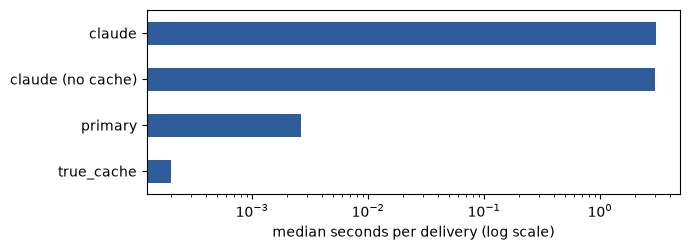

In [45]:
summary = results.groupby("served_by").agg(
    deliveries=("step", "count"),
    median_seconds=("seconds", "median"),
    llm_calls=("llm_calls", "sum"),
    estimated_usd=("estimated_usd", "sum"),
)
display(summary)
ax = (
    summary["median_seconds"]
    .sort_values()
    .plot.barh(logx=True, figsize=(7, 2.6), color="#2F5D9B")
)
ax.set_xlabel("median seconds per delivery (log scale)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6.3 · What the cache saved

Without the cache every delivery would call Claude. The counterfactual below prices each cached delivery
at the average cost of this run's real Claude calls. It is an estimate at list prices, not an invoice.

**What to watch:** many more deliveries than Claude calls, and an estimated saving of most of the
model spend for this workload.

In [46]:
cached = results[results.step != "baseline · no cache"]
per_call = results.loc[results.llm_calls > 0, "estimated_usd"].mean()
without = len(cached) * per_call
actual = cached.estimated_usd.sum()
print(
    f"Deliveries handled: {len(cached)} · Claude calls made: {int(cached.llm_calls.sum())}"
)
print(f"Estimated cost without cache: ${without:.4f} · with cache: ${actual:.4f}")
print(
    f"Estimated saving: ${without - actual:.4f} ({100 * (1 - actual / without):.0f}%)"
)

Deliveries handled: 16 · Claude calls made: 4
Estimated cost without cache: $0.0830 · with cache: $0.0211
Estimated saving: $0.0619 (75%)


## 6.4 · How to read the results

- **Repeats are where the value is.** Every redelivery after the first answer cost a primary-key lookup
  instead of a model call. The saving grows with the repeat rate of your traffic; with no repeats the
  cache only adds a lookup and a write per request.
- **The fallback covers the race.** A redelivery that arrives before the new row reaches True Cache is
  answered by the primary (rows served by `primary` above), not by a second model call. Once the row is
  applied, every worker reads it from True Cache.
- **Misses were the ones you want.** The edited issue, the new prompt version and the expired entry all
  called the model, because their answers could legitimately differ.
- **Invalidation was a single SQL statement** on the primary, with no cache-specific code.
- **This is one small run.** Latencies on a laptop with both databases local are not a production
  benchmark; measure with your own traffic.

## 6.5 · Production notes

- **Connection routing.** Keep separate pools for the primary and for True Cache and choose by intent:
  writes and read-after-write checks go to the primary, everything else to True Cache. Java applications
  on Oracle AI Database 26ai can use the JDBC Thin driver's single logical connection, which routes for
  you; with python-oracledb, two pools are the straightforward pattern.
- **Read-after-write lag.** True Cache is consistent but can be behind. Keep the primary fallback for
  cache lookups, and send any read that must see a just-committed change to the primary.
- **Sizing.** Give True Cache enough memory for the hot set of cache rows. Rows outside memory are still
  served, by fetching blocks from the primary on demand, just more slowly.
- **Several True Caches.** You can place True Caches near different application regions, or split data
  across several of them to build a larger in-memory tier.
- **An in-process cache in front.** For a handful of extremely hot keys, a small per-process dictionary
  with a very short expiry can sit in front of True Cache. It reintroduces staleness you must reason
  about, so keep its TTL to seconds.
- **Expiry and cleanup.** Reads ignore expired rows, but they still take space. Schedule a periodic
  `DELETE ... WHERE expires_at < SYSTIMESTAMP` on the primary (for example with `DBMS_SCHEDULER`).
- **Key hygiene.** Version the prompt, include the model and every generation parameter, scope by tenant,
  and never let the model see anything that is not in the key.
- **Side effects need their own idempotency.** The cache stops repeated *thinking*; applying labels twice
  is prevented by checking the issue's current labels or recording the delivery ID, not by the cache.

## 6.6 · Clean up

Delete only the rows this run wrote (triage answers and replication probes), identified by `RUN_ID`, on
the primary. The deletion reaches True Cache by itself. The table stays for the next run. Then close the
database connections and the Claude client.

In [47]:
with primary.cursor() as cursor:
    cursor.execute(f"DELETE FROM {TABLE} WHERE run_id = :run_id", run_id=RUN_ID)
    print("Deleted", cursor.rowcount, "rows written by this run")
primary.commit()
cache.close()
primary.close()
claude.close()

Deleted 8 rows written by this run


### Takeaways

- An exact-match cache turns repeated identical requests into millisecond lookups; at-least-once
  delivery makes such repeats routine for agents.
- Oracle True Cache gives the cache a shared, in-memory read tier that stays consistent with the primary
  through redo apply: same SQL, no invalidation code, writes only on the primary.
- Because True Cache can lag slightly, read it first and fall back to the primary before calling the
  model.
- Correctness lives in the key (scope, model, prompt version, limits, canonical input) and in expiry;
  True Cache keeps the copy in step, not the meaning.
- The cache is an idempotency record for computations, not the agent's memory of record and not proof
  that a side effect happened.